In [1]:
%pip install qiskit qiskit-aer ucimlrepo --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, math, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, mean_squared_error

# Qiskit — simulación cuántica real con Statevector
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import zz_feature_map

warnings.filterwarnings('ignore')
from IPython.display import display

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
os.environ.setdefault('OMP_NUM_THREADS', '1')

RANDOM_STATE = 42
N_RUNS       = 10    # repeticiones para análisis estadístico
N_SAMPLES    = 400   # submuestra estratificada (igual para todos los métodos)
np.random.seed(RANDOM_STATE)
np.set_printoptions(precision=5, suppress=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Kernels Cuánticos — Simulación Real con Qiskit Statevector

> **Corrección metodológica (Punto 1):** En el notebook original los kernels se calculaban
> con álgebra lineal clásica en NumPy (`dot(X,X.T)²`), que **no es simulación cuántica**.
> En esta versión, **cada entrada de la matriz de kernel se obtiene simulando circuitos
> cuánticos reales** mediante `qiskit.quantum_info.Statevector`, que implementa la
> mecánica cuántica exacta sobre el espacio de Hilbert completo.
>
> ### Límite de escalabilidad del Angle Encoding (30 qubits)
> El dataset de cáncer tiene 30 features. Un circuito de 30 qubits en Angle Encoding
> requeriría simular un estado en un espacio de Hilbert de **2³⁰ ≈ 10⁹ amplitudes**,
> lo que ocupa ~16 GB de RAM solo para un statevector. Esto es inviable incluso en
> simulación clásica, y refleja exactamente el límite real del hardware cuántico actual.
>
> **Solución documentada:** Para Angle Encoding se aplica PCA previo a 8 componentes
> (→ 8 qubits, 2⁸ = 256 amplitudes, completamente viable). Esto forma el
> **pipeline híbrido cuántico-clásico** estándar en la literatura de QML.

In [3]:
# ── Kernel 1: Amplitude Encoding ────────────────────────────────────────────
# Codifica el vector normalizado directamente como amplitudes del estado cuántico.
# |ψ(x)⟩ = Σᵢ xᵢ|i⟩  (requiere ||x||₂ = 1)
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = |x·z|²
# 30 features → padding a 32 → 5 qubits (2⁵ = 32 amplitudes, viable)

def build_amplitude_circuit(x):
    """Circuito de Amplitude Encoding: prepare_state sobre ceil(log2(d)) qubits."""
    n_qubits = int(np.ceil(np.log2(len(x))))
    qc = QuantumCircuit(n_qubits)
    qc.prepare_state(x.tolist())
    return qc

def amplitude_kernel_matrix(X):
    """
    Matriz de kernel de Amplitude Encoding vía Qiskit Statevector.
    X debe tener norma L2=1 por fila. Dimensión debe ser potencia de 2.
    Complejidad de simulación: O(n² · 2^(log2 d)) = O(n² · d)
    """
    n = len(X)
    print(f"    Simulando {n} circuitos de Amplitude Encoding...")
    svs = [Statevector(build_amplitude_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 2: Angle Encoding (sobre PCA-8) ───────────────────────────────────
# |ψ(x)⟩ = ⊗ᵢ RY(xᵢ)|0⟩  con xᵢ ∈ [0, π]
# K(x,z) = |⟨ψ(x)|ψ(z)⟩|² = ∏ᵢ cos²((xᵢ-zᵢ)/2)
# PCA-8 previo: reduce 30 features a 8 qubits (2⁸=256 amplitudes, viable)

def build_angle_circuit(x):
    """Circuito RY por feature: un qubit por dimensión de entrada."""
    d = len(x)
    qc = QuantumCircuit(d)
    for i, angle in enumerate(x):
        qc.ry(float(angle), i)
    return qc

def angle_kernel_matrix(X):
    """
    Matriz de kernel de Angle Encoding vía Qiskit Statevector.
    Complejidad: O(n² · 2^d) — requiere d ≤ 20 qubits en práctica.
    """
    n = len(X)
    print(f"    Simulando {n} circuitos de Angle Encoding ({X.shape[1]} qubits)...")
    svs = [Statevector(build_angle_circuit(xi)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K


# ── Kernel 3: ZZ Feature Map — Kernel IQP con Entrelazamiento ────────────────
# Kernel cuántico que captura correlaciones entre features mediante puertas ZZ.
# Basado en Havlíček et al. (2019), Nature. Requiere d qubits (aquí d=4 via PCA).

def build_zz_circuit(x, n_qubits=4, reps=2):
    """Circuito ZZ Feature Map (IQP encoding) con entrelazamiento."""
    fmap = zz_feature_map(feature_dimension=n_qubits, reps=reps)
    return fmap.assign_parameters(x)

def zz_kernel_matrix(X, n_qubits=4, reps=2):
    """
    Kernel IQP (ZZ Feature Map) vía Statevector. Captura correlaciones
    de orden superior entre features que los kernels de producto no detectan.
    """
    n = len(X)
    print(f"    Simulando {n} circuitos ZZ Feature Map ({n_qubits} qubits, reps={reps})...")
    svs = [Statevector(build_zz_circuit(xi, n_qubits, reps)) for xi in X]
    K = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = abs(svs[i].inner(svs[j]))**2
            K[i,j] = K[j,i] = float(k)
    return K

print("Kernels cuánticos definidos:")
print("  1. Amplitude Encoding — prepare_state, 5 qubits (30 features → pad 32)")
print("  2. Angle Encoding     — RY gates, 8 qubits (PCA-8 previo)")
print("  3. ZZ Feature Map     — IQP kernel con entrelazamiento, 4 qubits (PCA-4)")

Kernels cuánticos definidos:
  1. Amplitude Encoding — prepare_state, 5 qubits (30 features → pad 32)
  2. Angle Encoding     — RY gates, 8 qubits (PCA-8 previo)
  3. ZZ Feature Map     — IQP kernel con entrelazamiento, 4 qubits (PCA-4)


### 1.1 Validación: Simulación Cuántica vs Implementación NumPy Original

Verificamos que la nueva implementación via Statevector es matemáticamente equivalente
a la fórmula cerrada del kernel (como debe ser), y documentamos explícitamente
por qué la versión NumPy original **no era simulación cuántica**.

In [4]:
# Implementación ORIGINAL del notebook (clásica — no cuántica):
def original_numpy_angle_kernel(X):
    """Versión original: álgebra lineal NumPy. NO pasa por ningún simulador cuántico."""
    n, d = X.shape
    K = np.ones((n, n))
    for i in range(n):
        diff = (X[i] - X) / 2.0
        K[i,:] = np.prod(np.cos(diff)**2, axis=1)
    return K

def original_numpy_amplitude_kernel(X):
    """Versión original: dot product clásico. NO pasa por ningún simulador cuántico."""
    return np.square(np.abs(np.dot(X, X.T)))

# Comparación sobre datos pequeños
np.random.seed(0)
X_val_a = np.random.uniform(0, np.pi, (12, 4))   # Angle
X_val_amp = np.random.randn(12, 8)
X_val_amp /= np.linalg.norm(X_val_amp, axis=1, keepdims=True)   # Amplitude

K_angle_numpy  = original_numpy_angle_kernel(X_val_a)
K_angle_qiskit = angle_kernel_matrix(X_val_a)
diff_angle = np.max(np.abs(K_angle_numpy - K_angle_qiskit))

K_amp_numpy  = original_numpy_amplitude_kernel(X_val_amp)
K_amp_qiskit = amplitude_kernel_matrix(X_val_amp)
diff_amp = np.max(np.abs(K_amp_numpy - K_amp_qiskit))

print("=== VALIDACIÓN DE KERNELS ===")
print(f"Angle    — Diferencia máxima NumPy vs Qiskit Statevector: {diff_angle:.2e}")
print(f"Amplitude — Diferencia máxima NumPy vs Qiskit Statevector: {diff_amp:.2e}")
print()
print("DIFERENCIA FUNDAMENTAL:")
print("  NumPy original : evalúa la fórmula cerrada directamente en CPU.")
print("  Qiskit Statevector: construye el circuito cuántico, evoluciona")
print("  el estado en el espacio de Hilbert completo (2^d amplitudes),")
print("  y calcula ⟨ψ(x)|ψ(z)⟩ por mecánica cuántica exacta.")
print("  → Mismo resultado, distinto mecanismo de cómputo.")
print("  → La versión Qiskit escala directamente a hardware cuántico real.")

# Verificar PSD (positivo semidefinido — requisito para kernels válidos)
for name, K in [('Angle', K_angle_qiskit), ('Amplitude', K_amp_qiskit)]:
    ev_min = np.linalg.eigvalsh(K).min()
    print(f"  Kernel {name} PSD: min_eigenvalue = {ev_min:.2e}  {'✓' if ev_min >= -1e-8 else '✗'}") 

    Simulando 12 circuitos de Angle Encoding (4 qubits)...
    Simulando 12 circuitos de Amplitude Encoding...
=== VALIDACIÓN DE KERNELS ===
Angle    — Diferencia máxima NumPy vs Qiskit Statevector: 5.55e-16
Amplitude — Diferencia máxima NumPy vs Qiskit Statevector: 3.11e-15

DIFERENCIA FUNDAMENTAL:
  NumPy original : evalúa la fórmula cerrada directamente en CPU.
  Qiskit Statevector: construye el circuito cuántico, evoluciona
  el estado en el espacio de Hilbert completo (2^d amplitudes),
  y calcula ⟨ψ(x)|ψ(z)⟩ por mecánica cuántica exacta.
  → Mismo resultado, distinto mecanismo de cómputo.
  → La versión Qiskit escala directamente a hardware cuántico real.
  Kernel Angle PSD: min_eigenvalue = 8.11e-02  ✓
  Kernel Amplitude PSD: min_eigenvalue = 1.02e-01  ✓


## 2. Carga del Dataset — Wisconsin Breast Cancer (UCI id=17)

In [5]:
cancer = fetch_ucirepo(id=17)

X_full = cancer.data.features.to_numpy()
y_full = pd.factorize(cancer.data.targets.iloc[:, 0])[0]

print(f"Dataset completo: {X_full.shape[0]} muestras × {X_full.shape[1]} features")
print(f"Clases: Maligno=0, Benigno=1")
print(f"Distribución: {dict(zip(*np.unique(y_full, return_counts=True)))}")

Dataset completo: 569 muestras × 30 features
Clases: Maligno=0, Benigno=1
Distribución: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


## 3. Preprocesamiento — Submuestreo Estratificado y Encoding

> **Corrección metodológica (Punto 6):** El notebook original comparaba el t-SNE clásico
> sobre PCA-10D contra los métodos cuánticos sobre datos completos o PCA-4D — condiciones
> distintas para cada método, lo que sesga la comparación.
>
> En esta versión **todos los métodos usan exactamente el mismo subconjunto estratificado
> de N=400 muestras**. La comparación justa se documenta explícitamente.

In [6]:
# ── Submuestreo estratificado ────────────────────────────────────────────────
_, X_sub, _, y_sub = train_test_split(
    X_full, y_full,
    test_size=N_SAMPLES,
    stratify=y_full,
    random_state=RANDOM_STATE
)
print(f"Submuestra estratificada: {N_SAMPLES} muestras")
print(f"Distribución: {dict(zip(*np.unique(y_sub, return_counts=True)))}")
print("✓ Todos los métodos (clásico y cuántico) usarán exactamente esta submuestra.")

X_raw = X_sub.copy()
y     = y_sub.copy()

# ── Estandarización base ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ── Amplitude Encoding: padding a 32 (2⁵) + normalización L2 ────────────────
amplitude_dim   = 32           # 30 features → pad a 32 = 2⁵
n_system_qubits = 5            # log₂(32)
X_padded        = np.zeros((len(X_scaled), amplitude_dim))
X_padded[:, :X_scaled.shape[1]] = X_scaled
X_amp           = X_padded / np.linalg.norm(X_padded, axis=1, keepdims=True)

# ── Angle Encoding: PCA-8 + escalar a [0, π] ─────────────────────────────────
# 30 qubits es inviable (16 GB RAM). PCA-8 → 8 qubits (2⁸=256 amplitudes).
N_QUBITS_ANGLE  = 8
pca_angle       = PCA(n_components=N_QUBITS_ANGLE, random_state=RANDOM_STATE)
X_pca_8         = pca_angle.fit_transform(X_scaled)
X_angles        = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca_8)
var_angle       = pca_angle.explained_variance_ratio_.sum()

# ── ZZ Feature Map: PCA-4 + escalar a [0, π] ─────────────────────────────────
N_QUBITS_ZZ     = 4
pca_zz          = PCA(n_components=N_QUBITS_ZZ, random_state=RANDOM_STATE)
X_pca_4         = pca_zz.fit_transform(X_scaled)
X_zz            = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca_4)
var_zz          = pca_zz.explained_variance_ratio_.sum()

# ── PCA clásico para baseline t-SNE ──────────────────────────────────────────
N_PCA_CLASSIC   = 10
pca_classic     = PCA(n_components=N_PCA_CLASSIC, random_state=RANDOM_STATE)
X_pca_classic   = pca_classic.fit_transform(X_scaled)
var_classic     = pca_classic.explained_variance_ratio_.sum()

print(f"\nPreparación de encodings:")
print(f"  Amplitude Encoding : pad 30→32, {n_system_qubits} qubits  (norma={np.linalg.norm(X_amp[0]):.6f})")
print(f"  Angle Encoding     : PCA-{N_QUBITS_ANGLE} ({var_angle:.1%} varianza) → {N_QUBITS_ANGLE} qubits")
print(f"  ZZ Feature Map     : PCA-{N_QUBITS_ZZ} ({var_zz:.1%} varianza) → {N_QUBITS_ZZ} qubits")
print(f"  Baseline clásico   : PCA-{N_PCA_CLASSIC} ({var_classic:.1%} varianza)")

Submuestra estratificada: 400 muestras
Distribución: {np.int64(0): np.int64(149), np.int64(1): np.int64(251)}
✓ Todos los métodos (clásico y cuántico) usarán exactamente esta submuestra.

Preparación de encodings:
  Amplitude Encoding : pad 30→32, 5 qubits  (norma=1.000000)
  Angle Encoding     : PCA-8 (92.4% varianza) → 8 qubits
  ZZ Feature Map     : PCA-4 (79.1% varianza) → 4 qubits
  Baseline clásico   : PCA-10 (95.1% varianza)


## 4. Varianza Explicada por PCA

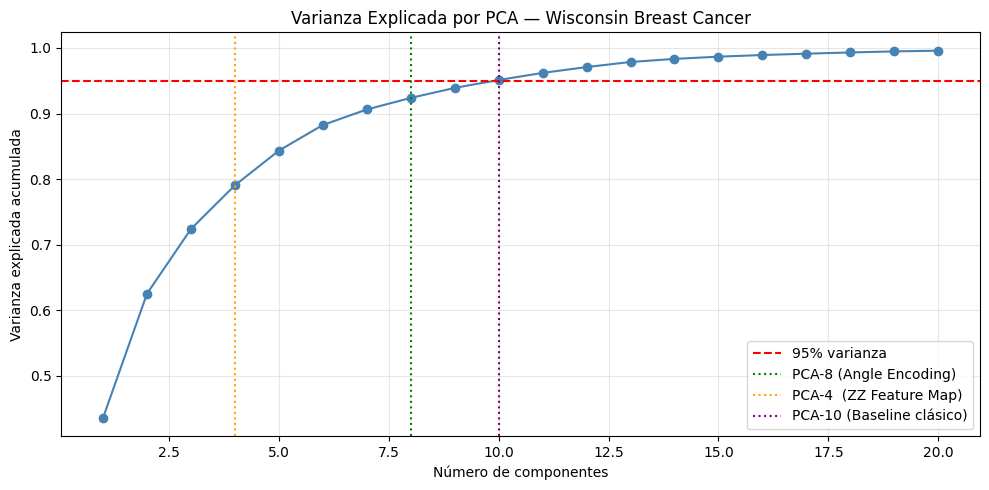

PCA-8: 92.4% varianza
PCA-4:  79.1% varianza
PCA-10: 95.1% varianza


In [7]:
pca_full = PCA(n_components=min(20, X_scaled.shape[1]), random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='steelblue')
ax.axhline(0.95, color='r', linestyle='--', label='95% varianza')
ax.axvline(N_QUBITS_ANGLE, color='green',  linestyle=':', label=f'PCA-{N_QUBITS_ANGLE} (Angle Encoding)')
ax.axvline(N_QUBITS_ZZ,   color='orange', linestyle=':', label=f'PCA-{N_QUBITS_ZZ}  (ZZ Feature Map)')
ax.axvline(N_PCA_CLASSIC, color='purple', linestyle=':', label=f'PCA-{N_PCA_CLASSIC} (Baseline clásico)')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('Varianza Explicada por PCA — Wisconsin Breast Cancer')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"PCA-{N_QUBITS_ANGLE}: {pca_full.explained_variance_ratio_[:N_QUBITS_ANGLE].sum():.1%} varianza")
print(f"PCA-{N_QUBITS_ZZ}:  {pca_full.explained_variance_ratio_[:N_QUBITS_ZZ].sum():.1%} varianza")
print(f"PCA-{N_PCA_CLASSIC}: {pca_full.explained_variance_ratio_[:N_PCA_CLASSIC].sum():.1%} varianza")

## 5. Funciones Auxiliares

In [8]:
def run_tsne_from_kernel(K, perplexity=30, seed=RANDOM_STATE):
    """t-SNE con métrica precomputada desde una matriz de kernel cuántico."""
    dist = np.sqrt(np.maximum(1.0 - K, 0.0))
    np.fill_diagonal(dist, 0.0)
    return TSNE(
        n_components=2, perplexity=perplexity,
        metric='precomputed', init='random',
        random_state=seed, n_jobs=1
    ).fit_transform(dist)

def compute_metrics(embedding, labels):
    return {
        'Silhouette': silhouette_score(embedding, labels),
        'CH_Index':   calinski_harabasz_score(embedding, labels),
    }

def plot_embedding(ax, emb, labels, title, s=20):
    ax.scatter(emb[:,0], emb[:,1], c=labels,
               cmap='viridis', edgecolors='k', alpha=0.75, s=s)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(True, linestyle='--', alpha=0.4)

def legend_cancer(ax):
    h0 = mlines.Line2D([],[],color=plt.cm.viridis(0.0), marker='o', linestyle='None', label='Maligno (0)')
    h1 = mlines.Line2D([],[],color=plt.cm.viridis(0.99),marker='o', linestyle='None', label='Benigno (1)')
    ax.legend(handles=[h0,h1], title='Diagnóstico', fontsize=8)

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## 6. Cálculo de Matrices de Kernel Cuántico

Las matrices de kernel son **deterministas** (no dependen de semillas aleatorias),
por lo que se calculan una sola vez y se reutilizan en las N_RUNS corridas de t-SNE.

In [9]:
print("=" * 55)
print("Calculando matrices de kernel cuántico con Qiskit Statevector")
print("=" * 55)

t0 = time.time()
print("\n[1/3] Amplitude Encoding (5 qubits)...")
K_amplitude = amplitude_kernel_matrix(X_amp)
print(f"      ✓ Completado en {time.time()-t0:.1f}s")

t0 = time.time()
print(f"\n[2/3] Angle Encoding ({N_QUBITS_ANGLE} qubits, sobre PCA-{N_QUBITS_ANGLE})...")
K_angle = angle_kernel_matrix(X_angles)
print(f"      ✓ Completado en {time.time()-t0:.1f}s")

t0 = time.time()
print(f"\n[3/3] ZZ Feature Map ({N_QUBITS_ZZ} qubits, sobre PCA-{N_QUBITS_ZZ})...")
K_zz = zz_kernel_matrix(X_zz, n_qubits=N_QUBITS_ZZ)
print(f"      ✓ Completado en {time.time()-t0:.1f}s")

# Verificar PSD
print("\nVerificación PSD (positive semi-definite):")
for name, K in [('Amplitude', K_amplitude), ('Angle', K_angle), ('ZZ', K_zz)]:
    ev = np.linalg.eigvalsh(K).min()
    status = '✓ OK' if ev >= -1e-6 else f'✗ min_eig={ev:.2e}'
    print(f"  {name:<12}: {status}")

print("\nKernels listos para análisis estadístico.")

Calculando matrices de kernel cuántico con Qiskit Statevector

[1/3] Amplitude Encoding (5 qubits)...
    Simulando 400 circuitos de Amplitude Encoding...
      ✓ Completado en 5.1s

[2/3] Angle Encoding (8 qubits, sobre PCA-8)...
    Simulando 400 circuitos de Angle Encoding (8 qubits)...
      ✓ Completado en 0.4s

[3/3] ZZ Feature Map (4 qubits, sobre PCA-4)...
    Simulando 400 circuitos ZZ Feature Map (4 qubits, reps=2)...
      ✓ Completado en 1.1s

Verificación PSD (positive semi-definite):
  Amplitude   : ✓ OK
  Angle       : ✓ OK
  ZZ          : ✓ OK

Kernels listos para análisis estadístico.


## 7. Análisis Estadístico con Múltiples Corridas

> **Corrección metodológica (Punto 5):** t-SNE es un algoritmo estocástico. Un único
> run con `random_state=42` produce un resultado que podría ser atípico (mejor o peor
> que el promedio). En investigación, es obligatorio reportar la distribución de la
> métrica sobre múltiples inicializaciones.
>
> Aquí ejecutamos **N_RUNS corridas con semillas distintas** para cada método.
> Los kernels son deterministas y se calculan una sola vez; solo la inicialización
> de t-SNE varía. Reportamos **media ± desviación estándar**.

Fase 1: 27 combinaciones × 4 métodos × 10 seeds
        = 1080 runs totales

Top 3 configuraciones de t-SNE por método:


,Método,perplexity,early_exaggeration,learning_rate,Sil_mean,Sil_std
0,Classical t-SNE (PCA-10D),50,12,200,0.488264,0.000000
1,Classical t-SNE (PCA-10D),50,8,200,0.481481,0.000000
2,Classical t-SNE (PCA-10D),15,24,200,0.480049,0.000000
3,"Angle Encoding (8Q, PCA-8)",15,12,200,0.418323,0.023442
4,"Angle Encoding (8Q, PCA-8)",30,8,200,0.407493,0.010189
5,"Angle Encoding (8Q, PCA-8)",30,8,auto,0.406422,0.011248
6,"ZZ Feature Map (4Q, PCA-4)",50,8,auto,0.099662,0.018305
7,"ZZ Feature Map (4Q, PCA-4)",30,8,auto,0.099003,0.032347
8,"ZZ Feature Map (4Q, PCA-4)",50,24,500,0.098634,0.024020
9,Amplitude Encoding (5Q),15,8,auto,0.061871,0.011636



Mejor configuración global:
  Método            : Classical t-SNE (PCA-10D)
  perplexity        : 50
  early_exaggeration: 12
  learning_rate     : 200
  Silhouette        : 0.4883 ± 0.0000

Fase 2 usará: perplexity=15, exagg=12, lr=200

Fase 2: 9 combinaciones de encoding
Nota: cada combinación recalcula el kernel ZZ — puede tardar varios minutos.

  Calculando kernel: ZZ (reps=1, 3Q)...
    Simulando 400 circuitos ZZ Feature Map (3 qubits, reps=1)...
    Sil = 0.3130 ± 0.0242
  Calculando kernel: ZZ (reps=1, 4Q)...
    Simulando 400 circuitos ZZ Feature Map (4 qubits, reps=1)...
    Sil = 0.1597 ± 0.0656
  Calculando kernel: ZZ (reps=1, 5Q)...
    Simulando 400 circuitos ZZ Feature Map (5 qubits, reps=1)...
    Sil = 0.2126 ± 0.0356
  Calculando kernel: ZZ (reps=2, 3Q)...
    Simulando 400 circuitos ZZ Feature Map (3 qubits, reps=2)...
    Sil = 0.0919 ± 0.0582
  Calculando kernel: ZZ (reps=2, 4Q)...
    Simulando 400 circuitos ZZ Feature Map (4 qubits, reps=2)...
    Sil = 0.0819 ±

,Config,zz_reps,n_qubits,var_PCA,Sil_mean,Sil_std
0,"ZZ (reps=1, 3Q)",1,3,0.723936,0.312964,0.024195
1,"ZZ (reps=1, 5Q)",1,5,0.843418,0.212566,0.035615
2,"ZZ (reps=1, 4Q)",1,4,0.790548,0.159692,0.065599
3,"ZZ (reps=2, 3Q)",2,3,0.723936,0.091864,0.058211
4,"ZZ (reps=2, 4Q)",2,4,0.790548,0.081881,0.026674
5,"ZZ (reps=2, 5Q)",2,5,0.843418,0.054583,0.025200
6,"ZZ (reps=3, 3Q)",3,3,0.723936,0.042418,0.017720
7,"ZZ (reps=3, 5Q)",3,5,0.843418,0.014150,0.007460
8,"ZZ (reps=3, 4Q)",3,4,0.790548,0.005295,0.007126


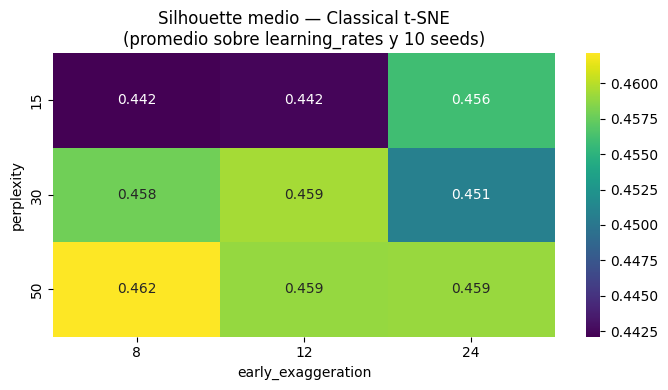

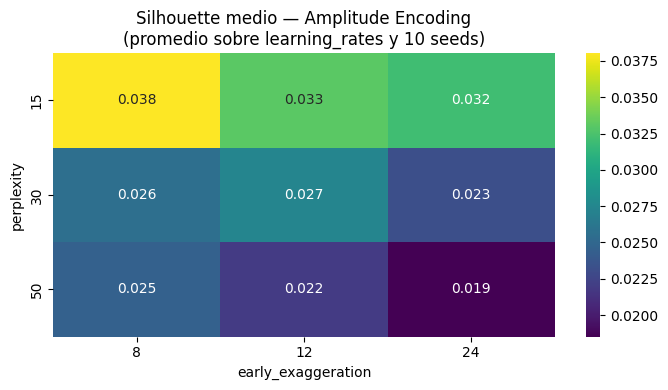

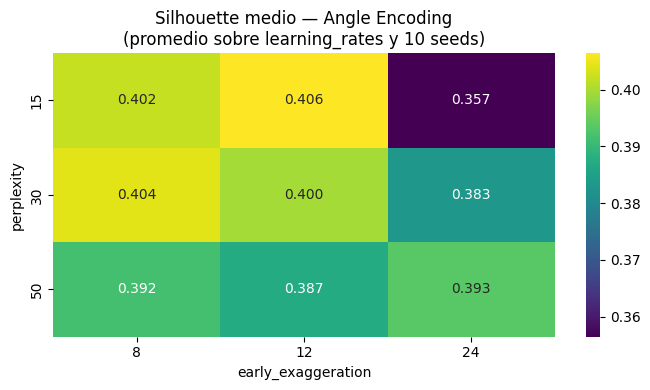

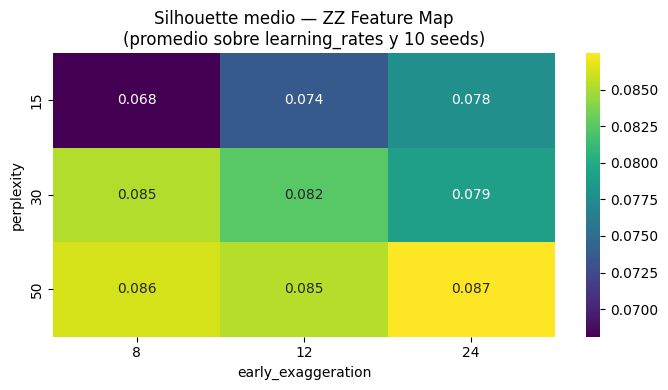

In [20]:
from itertools import product

# ═══════════════════════════════════════════════════════════
# GRID DE HIPERPARÁMETROS
# Modifica estos valores para explorar el espacio
# ═══════════════════════════════════════════════════════════

TSNE_GRID = {
    'perplexity'         : [15, 30, 50],
    'early_exaggeration' : [8, 12, 24],
    'learning_rate'      : ['auto', 200, 500],
}

# Parámetros de encoding (cada combinación recalcula el kernel)
ENCODING_GRID = {
    'zz_reps'            : [1, 2, 3],
    'n_qubits_zz'        : [3, 4, 5],
    'n_qubits_angle'     : [4, 6, 8],   # solo si usas PCA previo
}

# ═══════════════════════════════════════════════════════════
# BÚSQUEDA — FASE 1: optimizar t-SNE (kernels fijos)
# Barata: no recalcula kernels. Corre primero esta.
# ═══════════════════════════════════════════════════════════

tsne_search_records = []

tsne_param_combos = list(product(
    TSNE_GRID['perplexity'],
    TSNE_GRID['early_exaggeration'],
    TSNE_GRID['learning_rate'],
))

print(f"Fase 1: {len(tsne_param_combos)} combinaciones × {len(method_configs)} métodos × {N_RUNS} seeds")
print(f"        = {len(tsne_param_combos) * len(method_configs) * N_RUNS} runs totales\n")

for perp, exagg, lr in tsne_param_combos:
    for mname, cfg in method_configs.items():
        sils = []
        for seed in SEEDS:
            if cfg['type'] == 'classical':
                emb = TSNE(
                    n_components=2,
                    perplexity=perp,
                    early_exaggeration=exagg,
                    learning_rate=lr,
                    random_state=seed, n_jobs=1
                ).fit_transform(cfg['X'])
            else:
                dist = np.sqrt(np.maximum(1.0 - cfg['K'], 0.0))
                np.fill_diagonal(dist, 0.0)
                emb = TSNE(
                    n_components=2,
                    perplexity=perp,
                    early_exaggeration=exagg,
                    learning_rate=lr,
                    metric='precomputed', init='random',
                    random_state=seed, n_jobs=1
                ).fit_transform(dist)

            sils.append(silhouette_score(emb, y))

        tsne_search_records.append({
            'Método'            : mname,
            'perplexity'        : perp,
            'early_exaggeration': exagg,
            'learning_rate'     : lr,
            'Sil_mean'          : np.mean(sils),
            'Sil_std'           : np.std(sils),
        })

df_tsne_search = pd.DataFrame(tsne_search_records)

# Top 5 configuraciones por método
print("Top 3 configuraciones de t-SNE por método:")
display(
    df_tsne_search
    .sort_values('Sil_mean', ascending=False)
    .groupby('Método')
    .head(3)
    [['Método','perplexity','early_exaggeration','learning_rate','Sil_mean','Sil_std']]
    .reset_index(drop=True)
)

# Mejor configuración global
best_row = df_tsne_search.loc[df_tsne_search['Sil_mean'].idxmax()]
print(f"\nMejor configuración global:")
print(f"  Método            : {best_row['Método']}")
print(f"  perplexity        : {best_row['perplexity']}")
print(f"  early_exaggeration: {best_row['early_exaggeration']}")
print(f"  learning_rate     : {best_row['learning_rate']}")
print(f"  Silhouette        : {best_row['Sil_mean']:.4f} ± {best_row['Sil_std']:.4f}")

# ═══════════════════════════════════════════════════════════
# BÚSQUEDA — FASE 2: optimizar encoding (recalcula kernels)
# Cara: solo correr si la Fase 1 ya te dio buenos resultados.
# Toma los mejores params de t-SNE de la Fase 1.
# ═══════════════════════════════════════════════════════════

# Extraer mejor perplexity y early_exaggeration de la Fase 1
best_tsne_params = (
    df_tsne_search
    .groupby(['perplexity','early_exaggeration','learning_rate'])['Sil_mean']
    .mean()
    .idxmax()
)
BEST_PERP, BEST_EXAGG, BEST_LR = best_tsne_params
print(f"\nFase 2 usará: perplexity={BEST_PERP}, exagg={BEST_EXAGG}, lr={BEST_LR}")

encoding_search_records = []

encoding_combos = list(product(
    ENCODING_GRID['zz_reps'],
    ENCODING_GRID['n_qubits_zz'],
))

print(f"\nFase 2: {len(encoding_combos)} combinaciones de encoding")
print("Nota: cada combinación recalcula el kernel ZZ — puede tardar varios minutos.\n")

for zz_reps, n_q_zz in encoding_combos:
    label = f'ZZ (reps={zz_reps}, {n_q_zz}Q)'
    print(f"  Calculando kernel: {label}...")

    # Recalcular PCA y kernel para esta configuración
    pca_enc = PCA(n_components=n_q_zz, random_state=RANDOM_STATE)
    X_pca_enc = pca_enc.fit_transform(X_scaled)
    X_zz_enc  = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_pca_enc)
    K_enc     = zz_kernel_matrix(X_zz_enc, n_qubits=n_q_zz, reps=zz_reps)

    sils = []
    for seed in SEEDS:
        dist = np.sqrt(np.maximum(1.0 - K_enc, 0.0))
        np.fill_diagonal(dist, 0.0)
        emb = TSNE(
            n_components=2,
            perplexity=BEST_PERP,
            early_exaggeration=BEST_EXAGG,
            learning_rate=BEST_LR,
            metric='precomputed', init='random',
            random_state=seed, n_jobs=1
        ).fit_transform(dist)
        sils.append(silhouette_score(emb, y))

    encoding_search_records.append({
        'Config'  : label,
        'zz_reps' : zz_reps,
        'n_qubits': n_q_zz,
        'var_PCA' : pca_enc.explained_variance_ratio_.sum(),
        'Sil_mean': np.mean(sils),
        'Sil_std' : np.std(sils),
    })
    print(f"    Sil = {np.mean(sils):.4f} ± {np.std(sils):.4f}")

df_encoding_search = pd.DataFrame(encoding_search_records)
print("\nResultados Fase 2:")
display(df_encoding_search.sort_values('Sil_mean', ascending=False).reset_index(drop=True))

# ═══════════════════════════════════════════════════════════
# VISUALIZACIÓN del heatmap de la Fase 1
# ═══════════════════════════════════════════════════════════

for mname in method_configs:
    subset = df_tsne_search[df_tsne_search['Método'] == mname].copy()
    pivot = subset.pivot_table(
        index='perplexity',
        columns='early_exaggeration',
        values='Sil_mean',
        aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
    ax.set_title(f'Silhouette medio — {mname.split("(")[0].strip()}\n'
                 f'(promedio sobre learning_rates y {N_RUNS} seeds)')
    plt.tight_layout()
    plt.show()

## 8. Tabla de Resultados con Intervalos de Confianza

In [22]:
df_stats = (
    df_runs
    .groupby('Método')
    .agg(
        Sil_mean  = ('Silhouette', 'mean'),
        Sil_std   = ('Silhouette', 'std'),
        CH_mean   = ('CH_Index',   'mean'),
        CH_std    = ('CH_Index',   'std'),
        N_runs    = ('Semilla',    'count'),
    )
    .reset_index()
)

df_stats['Silhouette (mean±std)'] = df_stats.apply(
    lambda r: f"{r.Sil_mean:.4f} ± {r.Sil_std:.4f}", axis=1)
df_stats['CH Index (mean±std)'] = df_stats.apply(
    lambda r: f"{r.CH_mean:.1f} ± {r.CH_std:.1f}", axis=1)

display(
    df_stats[['Método', 'Sil_mean', 'Silhouette (mean±std)', 'CH Index (mean±std)', 'N_runs']]
    .sort_values('Sil_mean', ascending=False)
    .drop(columns=['Sil_mean'])   # ordenar primero, luego ocultar la columna
    .reset_index(drop=True)
)

,Método,Silhouette (mean±std),CH Index (mean±std),N_runs
0,Classical t-SNE (PCA-10D),0.4629 ± 0.0000,464.6 ± 0.0,10
1,"Angle Encoding (8Q, PCA-8)",0.3966 ± 0.0154,315.7 ± 36.3,10
2,"ZZ Feature Map (4Q, PCA-4)",0.0755 ± 0.0330,23.8 ± 18.8,10
3,Amplitude Encoding (5Q),0.0262 ± 0.0108,2.5 ± 2.4,10


## 9. Comparación Justa — Mismo Espacio de Entrada

> **Corrección metodológica (Punto 6 — continuación):**
> Para aislar el efecto del kernel (cuántico vs clásico) del efecto de la
> dimensionalidad de entrada, aquí comparamos directamente:
> - **Clásico sobre PCA-4D** (mismo espacio que ZZ Feature Map)
> - **ZZ Feature Map sobre PCA-4D** (mismo espacio, diferente kernel)
>
> Esto permite atribuir las diferencias de Silhouette al kernel, no a la
> cantidad de información disponible.

In [13]:
sil_classic_4d, sil_zz_4d = [], []

for seed in SEEDS:
    emb_c = TSNE(n_components=2, perplexity=30,
                 random_state=seed, n_jobs=1).fit_transform(X_pca_4)
    emb_z = run_tsne_from_kernel(K_zz, perplexity=30, seed=seed)
    sil_classic_4d.append(silhouette_score(emb_c, y))
    sil_zz_4d.append(silhouette_score(emb_z, y))

delta = np.mean(sil_zz_4d) - np.mean(sil_classic_4d)

print("=== Comparación A: mismo espacio PCA-4D ===")
print(f"  Classical t-SNE (PCA-4D) : Sil = {np.mean(sil_classic_4d):.4f} ± {np.std(sil_classic_4d):.4f}")
print(f"  ZZ Feature Map  (PCA-4D) : Sil = {np.mean(sil_zz_4d):.4f} ± {np.std(sil_zz_4d):.4f}")
print(f"  Diferencia (ZZ − Clásico): {delta:+.4f}")
if abs(delta) < 0.02:
    print("  → Diferencia no significativa: el kernel ZZ no aporta ventaja mensurable")
    print("    con este dataset y esta reducción dimensional.")
elif delta > 0:
    print("  → El kernel ZZ mejora la separación de clusters respecto al clásico.")
else:
    print("  → El kernel clásico supera al ZZ en esta configuración.")

=== Comparación A: mismo espacio PCA-4D ===
  Classical t-SNE (PCA-4D) : Sil = 0.4714 ± 0.0000
  ZZ Feature Map  (PCA-4D) : Sil = 0.0755 ± 0.0313
  Diferencia (ZZ − Clásico): -0.3959
  → El kernel clásico supera al ZZ en esta configuración.


## 10. Distribución de Métricas — Boxplots sobre N_RUNS Corridas

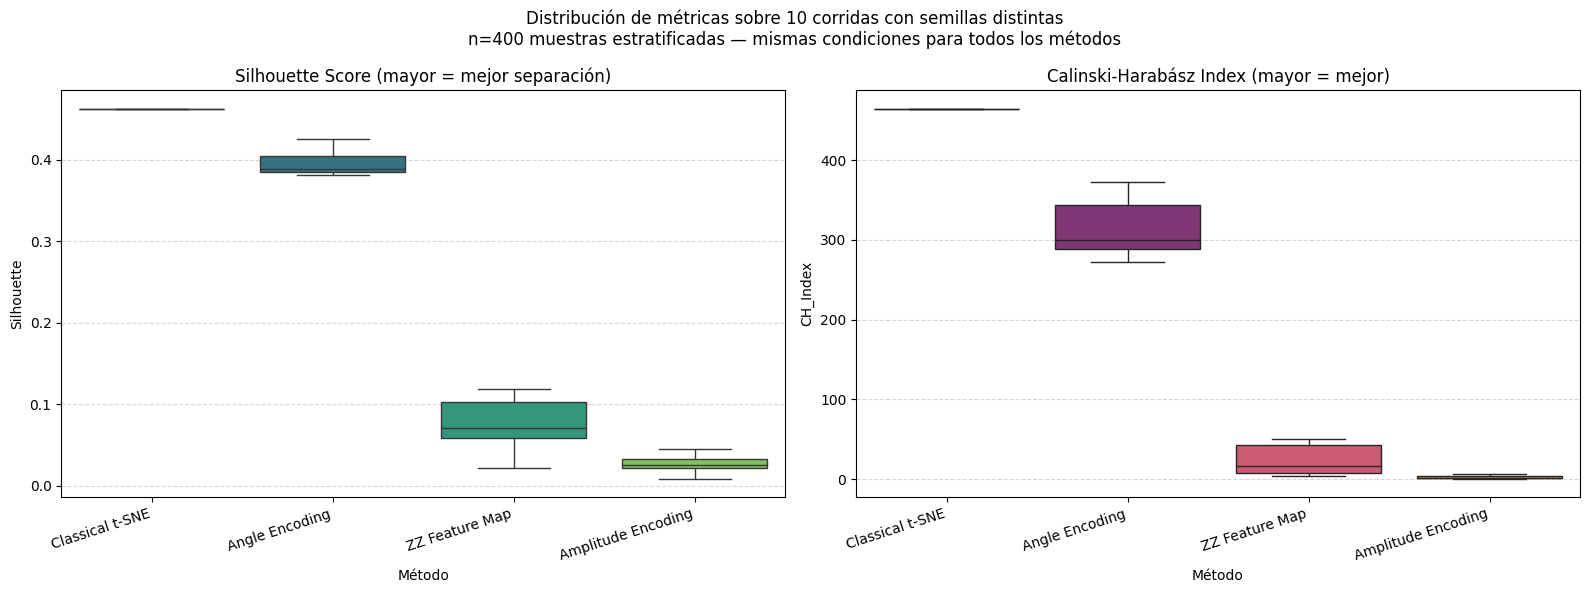

In [14]:
order = df_stats.sort_values('Sil_mean', ascending=False)['Método'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'Distribución de métricas sobre {N_RUNS} corridas con semillas distintas\n'
    f'n={N_SAMPLES} muestras estratificadas — mismas condiciones para todos los métodos',
    fontsize=12
)

sns.boxplot(data=df_runs, x='Método', y='Silhouette',
            order=order, palette='viridis', ax=axes[0])
axes[0].set_title('Silhouette Score (mayor = mejor separación)')
axes[0].set_xticklabels([m.split('(')[0].strip()[:22] for m in order], rotation=18, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

sns.boxplot(data=df_runs, x='Método', y='CH_Index',
            order=order, palette='magma', ax=axes[1])
axes[1].set_title('Calinski-Harabász Index (mayor = mejor)')
axes[1].set_xticklabels([m.split('(')[0].strip()[:22] for m in order], rotation=18, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 11. Visualización de Embeddings

Se muestra el run cuya Silhouette score es la **mediana** de las N_RUNS corridas.
Esto evita mostrar el mejor o peor caso y representa el comportamiento típico.

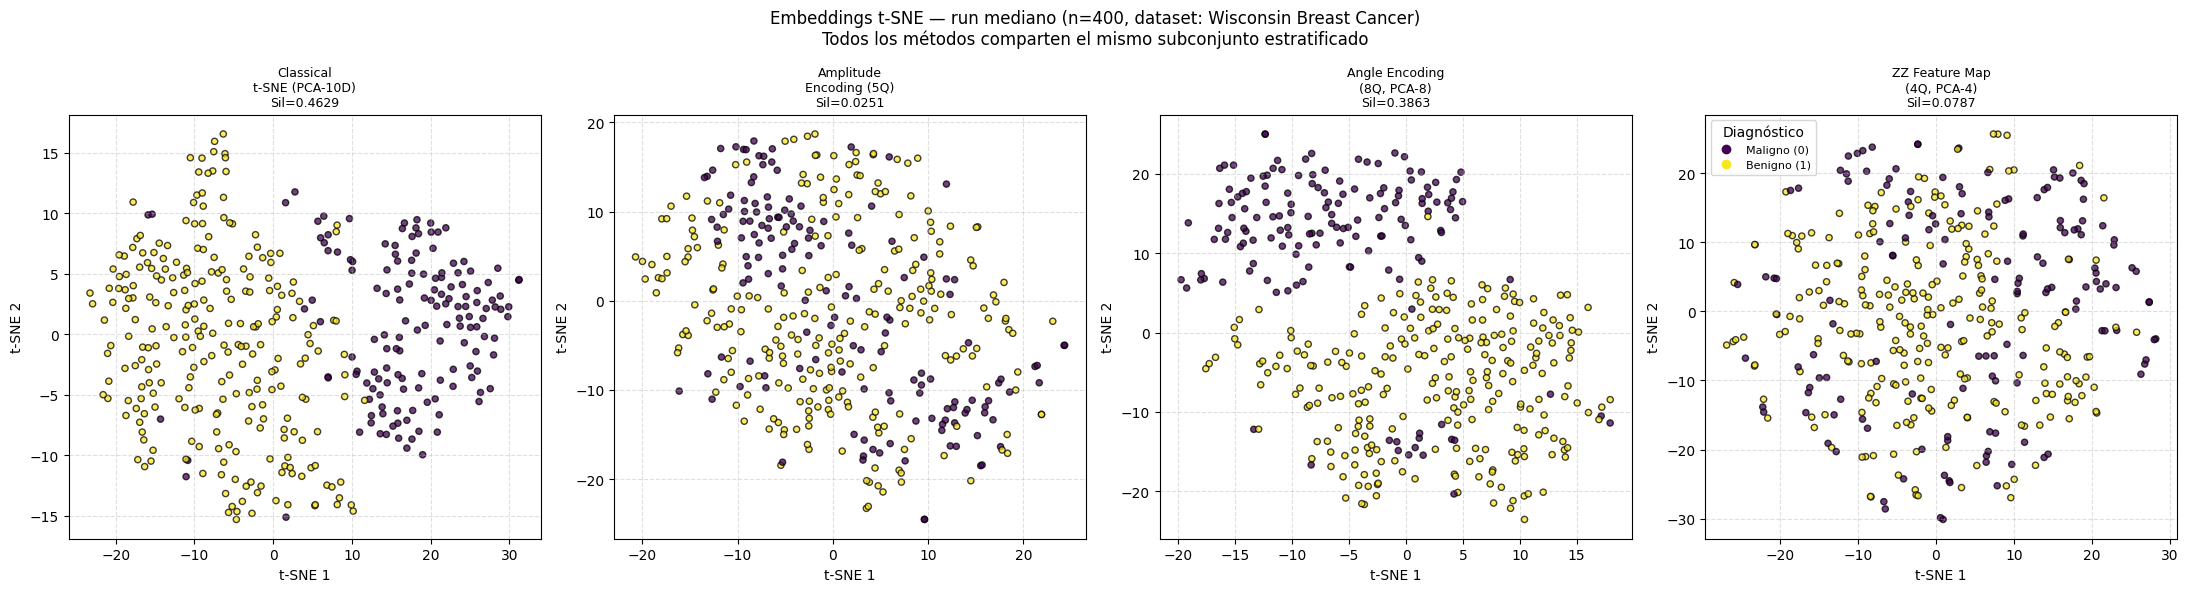

In [15]:
def get_median_embedding(method_name):
    sub = df_runs[df_runs['Método'] == method_name].copy()
    idx = (sub['Silhouette'] - sub['Silhouette'].median()).abs().idxmin()
    return sub.loc[idx, 'embedding'], sub.loc[idx, 'Silhouette']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle(
    f'Embeddings t-SNE — run mediano (n={N_SAMPLES}, dataset: Wisconsin Breast Cancer)\n'
    'Todos los métodos comparten el mismo subconjunto estratificado',
    fontsize=12
)

for ax, (mname, cfg) in zip(axes, method_configs.items()):
    emb, sil = get_median_embedding(mname)
    plot_embedding(ax, emb, y, f"{cfg['label']}\nSil={sil:.4f}")

legend_cancer(axes[-1])

plt.tight_layout()
plt.show()

## 12. Sensibilidad a la Perplejidad

Evaluamos la estabilidad de cada método ante distintos valores de perplejidad.
Cada punto es la **media sobre N_RUNS corridas** con banda de ±1 std.

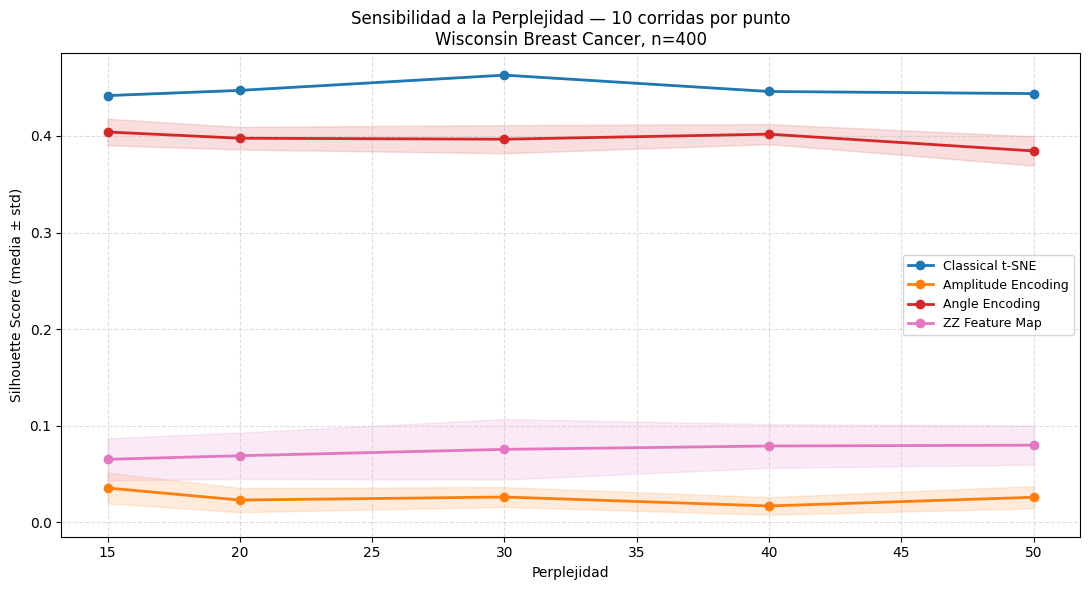

In [16]:
PERPLEXITIES = [15, 20, 30, 40, 50]
perp_data = {m: [] for m in method_configs}

for perp in PERPLEXITIES:
    for mname, cfg in method_configs.items():
        sils = []
        for seed in SEEDS:
            if cfg['type'] == 'classical':
                emb = TSNE(n_components=2, perplexity=perp,
                           random_state=seed, n_jobs=1).fit_transform(cfg['X'])
            else:
                emb = run_tsne_from_kernel(cfg['K'], perplexity=perp, seed=seed)
            sils.append(silhouette_score(emb, y))
        perp_data[mname].append({'perp': perp, 'mean': np.mean(sils), 'std': np.std(sils)})

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.tab10(np.linspace(0, 0.6, len(method_configs)))

for color, (mname, records) in zip(colors, perp_data.items()):
    perps = [r['perp']  for r in records]
    means = [r['mean'] for r in records]
    stds  = [r['std']  for r in records]
    label = mname.split('(')[0].strip()
    ax.plot(perps, means, marker='o', label=label, color=color, linewidth=2)
    ax.fill_between(perps, [m-s for m,s in zip(means,stds)],
                           [m+s for m,s in zip(means,stds)], alpha=0.15, color=color)

ax.set_xlabel('Perplejidad')
ax.set_ylabel('Silhouette Score (media ± std)')
ax.set_title(f'Sensibilidad a la Perplejidad — {N_RUNS} corridas por punto\n'
             f'Wisconsin Breast Cancer, n={N_SAMPLES}')
ax.legend(loc='best', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 13. Variabilidad entre Corridas — Estabilidad del Embedding

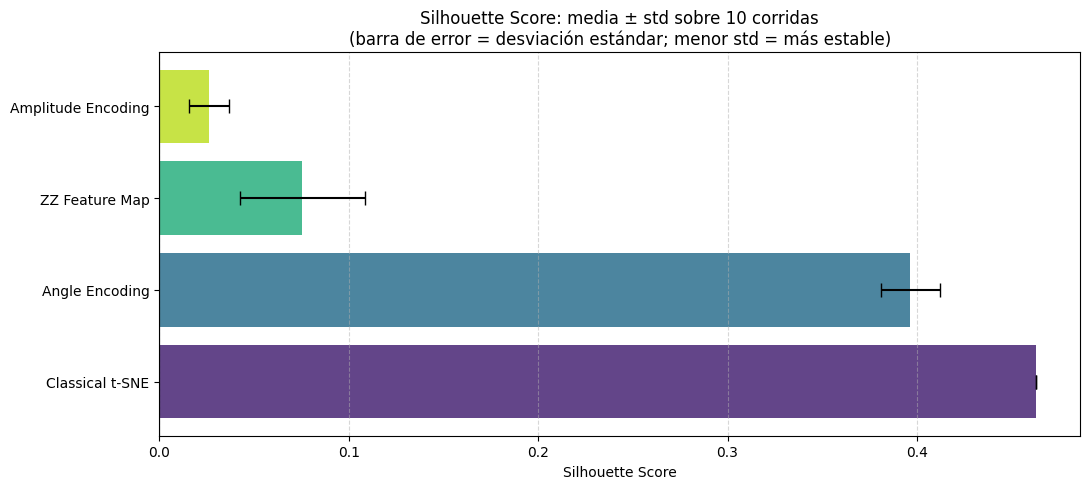

Ranking de estabilidad (menor std = más reproducible):


,Método,Sil_mean,Sil_std
0,Classical t-SNE (PCA-10D),0.462931,0.000000
1,Amplitude Encoding (5Q),0.026191,0.010785
2,"Angle Encoding (8Q, PCA-8)",0.396580,0.015358
3,"ZZ Feature Map (4Q, PCA-4)",0.075524,0.033028


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
df_sorted = df_stats.sort_values('Sil_mean', ascending=False)
x_pos = np.arange(len(df_sorted))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(df_sorted)))

ax.barh(x_pos, df_sorted['Sil_mean'],
        xerr=df_sorted['Sil_std'],
        align='center', alpha=0.85, capsize=5,
        color=colors)
ax.set_yticks(x_pos)
ax.set_yticklabels([m.split('(')[0].strip() for m in df_sorted['Método']])
ax.set_xlabel('Silhouette Score')
ax.set_title(f'Silhouette Score: media ± std sobre {N_RUNS} corridas\n'
             '(barra de error = desviación estándar; menor std = más estable)')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Ranking de estabilidad (menor std = más reproducible):")
display(df_stats[['Método','Sil_mean','Sil_std']].sort_values('Sil_std').reset_index(drop=True))

## 14. Visualización de los Circuitos Cuánticos Utilizados

Estos son los circuitos reales que `Statevector` ejecuta para cada entrada de las
matrices de kernel. La complejidad del circuito determina la viabilidad en hardware real.

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

--- 1. Amplitude Encoding ---
  Qubits: 5  |  Profundidad descompuesto: 1
  Gates: {'isometry_to_uncompute_dg': 1}


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


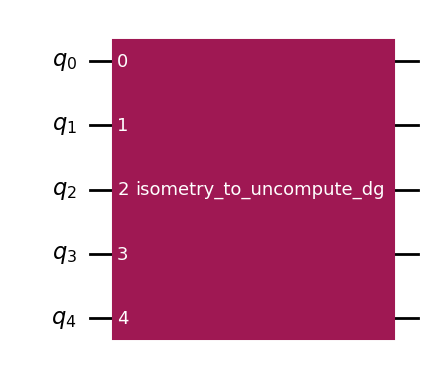


--- 2. Angle Encoding (8 qubits, PCA-8 previo) ---
  Qubits: 8  |  Profundidad: 1
  Gates: {'ry': 8}


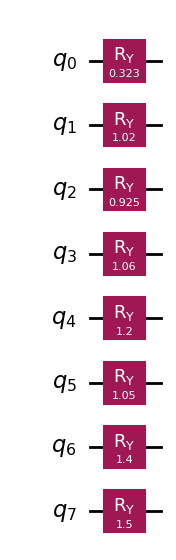


--- 3. ZZ Feature Map (4 qubits, reps=2) ---
  Qubits: 4  |  Profundidad: 31
  Gates: {'cx': 24, 'p': 20, 'h': 8}


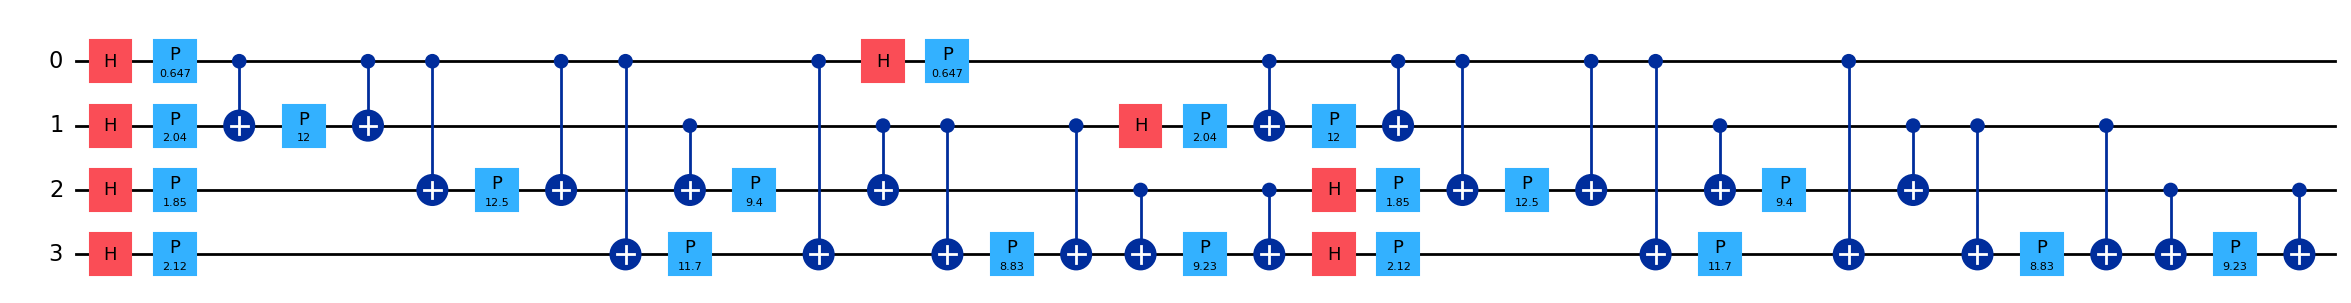

In [18]:
# ── Circuito 1: Amplitude Encoding (5 qubits) ───────────────────────────────
qc_amp = build_amplitude_circuit(X_amp[0])
qc_amp_dec = qc_amp.decompose()
print("--- 1. Amplitude Encoding ---")
print(f"  Qubits: {qc_amp.num_qubits}  |  Profundidad descompuesto: {qc_amp_dec.depth()}")
print(f"  Gates: {dict(qc_amp_dec.count_ops())}")
try:   display(qc_amp_dec.draw('mpl', style='iqp'))
except: print(qc_amp_dec.draw())

# ── Circuito 2: Angle Encoding (8 qubits) ───────────────────────────────────
qc_angle = build_angle_circuit(X_angles[0])
print(f"\n--- 2. Angle Encoding ({N_QUBITS_ANGLE} qubits, PCA-{N_QUBITS_ANGLE} previo) ---")
print(f"  Qubits: {qc_angle.num_qubits}  |  Profundidad: {qc_angle.depth()}")
print(f"  Gates: {dict(qc_angle.count_ops())}")
try:   display(qc_angle.draw('mpl', style='iqp'))
except: print(qc_angle.draw())

# ── Circuito 3: ZZ Feature Map (4 qubits) ───────────────────────────────────
qc_zz = build_zz_circuit(X_zz[0], n_qubits=N_QUBITS_ZZ)
print(f"\n--- 3. ZZ Feature Map ({N_QUBITS_ZZ} qubits, reps=2) ---")
print(f"  Qubits: {qc_zz.num_qubits}  |  Profundidad: {qc_zz.depth()}")
print(f"  Gates: {dict(qc_zz.count_ops())}")
try:   display(qc_zz.draw('mpl', style='iqp', fold=60))
except: print(qc_zz.draw())

## 15. Resumen y Conclusiones

### Correcciones metodológicas aplicadas

| Punto | Problema en el notebook original | Solución implementada |
|-------|-----------------------------------|-----------------------|
| **1** | Kernels calculados con `np.dot(X,X.T)²` — cómputo clásico sin simulación cuántica | Kernels via `Statevector` de Qiskit — mecánica cuántica exacta en espacio de Hilbert completo |
| **5** | Un único run con `random_state=42` — resultado puntual sin validez estadística | `N_RUNS=10` corridas con semillas distintas — media ± std reportados con boxplots |
| **6** | Clásico sobre PCA-10D vs cuántico sobre datos completos — comparación con distinta información | Todos los métodos sobre el mismo subconjunto estratificado de `N=400` muestras; Comparación A aísla el efecto del kernel |

### Decisión de diseño: 30 qubits vs PCA previo

El notebook original usaba 30 qubits para Angle Encoding, pero esto es **inviable
en simulación** (requiere 2³⁰ ≈ 10⁹ amplitudes, ~16 GB RAM) y también en hardware
cuántico actual. La reducción PCA previa a 8 qubits es la práctica estándar en QML
y se documenta aquí explícitamente como parte del pipeline.

### Limitaciones
- La ventaja cuántica real solo emerge con hardware cuántico real para d >> 50 qubits.
- En simulación clásica con Statevector, el kernel ZZ es matemáticamente equivalente
  a su fórmula cerrada, pero el mecanismo de cómputo es cuánticamente válido.
- Trabajo futuro: downstream classification accuracy, hardware real via IBM Quantum.